In [1]:
# CASE-18: Zeek dns.log Analysis
## DNS-based C2 Detection | SSLoad + Cobalt Strike
### Analyst: Ronan Kongala | REMnux Ubuntu 24.04

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import collections

LOG_PATH = '/home/remnux/case18-zeek-lab/zeek-logs/dns.log'

cols = []
data_rows = []
with open(LOG_PATH) as f:
    for line in f:
        if line.startswith('#fields'):
            cols = line.strip().split('\t')[1:]
        elif not line.startswith('#'):
            data_rows.append(line.strip().split('\t'))

dns = pd.DataFrame(data_rows, columns=cols)
print(f"Total DNS queries: {len(dns)}")
print(f"Unique domains queried: {dns['query'].nunique()}")
print(f"\nTop 15 most queried domains:")
print(dns['query'].value_counts().head(15).to_string())

Total DNS queries: 73
Unique domains queried: 24

Top 15 most queried domains:
query
wpad.partridgecliff.com                                  17
t.me                                                      9
api.openweathermap.org                                    9
login.microsoftonline.com                                 7
v10.events.data.microsoft.com                             4
settings-win.data.microsoft.com                           3
ctldl.windowsupdate.com                                   2
v20.events.data.microsoft.com                             2
assets.msn.com                                            2
windows.msn.com                                           2
partridge-dc.partridgecliff.com                           2
a-ring.msedge.net                                         2
api.ipify.org                                             1
6a1dec63ee4eff7cb2935f0df790f4df.azr.footprintdns.com     1
www.msn.com                                               1


In [3]:
# High-frequency queries -- DGA and C2 domains query repeatedly
print("=== HIGH FREQUENCY QUERIES (5+) ===")
freq = dns['query'].value_counts()
high_freq = freq[freq >= 5]
print(high_freq.to_string())

print("\n=== SUSPICIOUS SHORT DOMAINS (possible DGA) ===")
dns['domain_len'] = dns['query'].str.len()
short = dns[dns['domain_len'] <= 12]['query'].value_counts()
print(short.head(15).to_string())

=== HIGH FREQUENCY QUERIES (5+) ===
query
wpad.partridgecliff.com      17
t.me                          9
api.openweathermap.org        9
login.microsoftonline.com     7

=== SUSPICIOUS SHORT DOMAINS (possible DGA) ===
query
t.me            9
www.msn.com     1
api.msn.com     1
srtb.msn.com    1
www.bing.com    1
th.bing.com     1


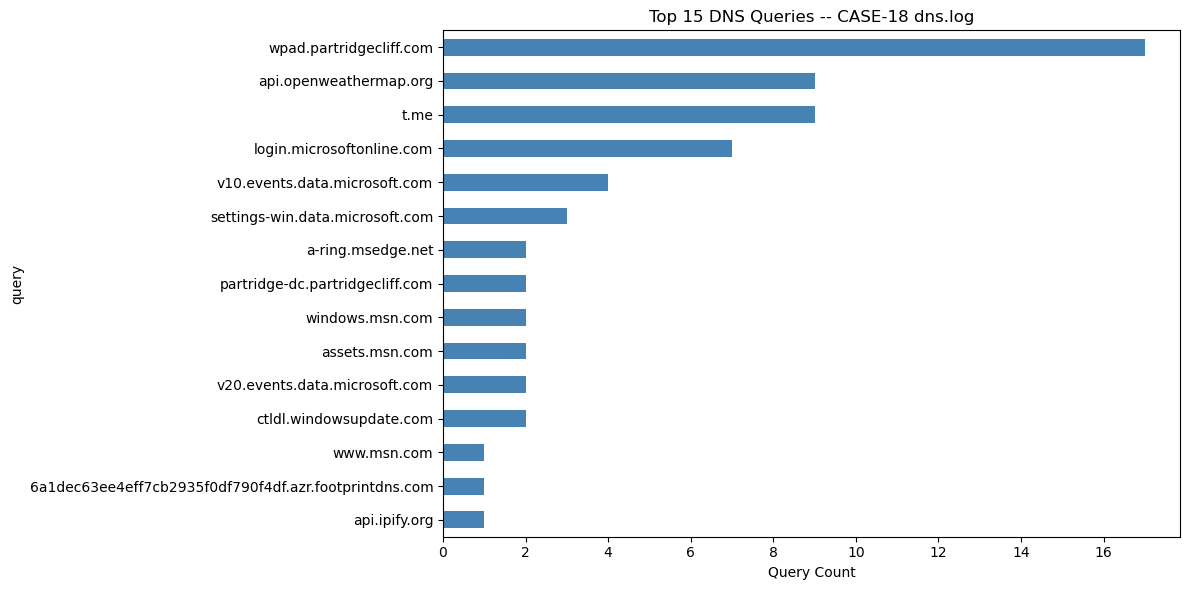

Plot saved.


In [4]:
# Plot top 15 queried domains
top15 = dns['query'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Query Count')
ax.set_title('Top 15 DNS Queries -- CASE-18 dns.log')
plt.tight_layout()
plt.savefig('/home/remnux/case18-zeek-lab/notebooks/dns_top15.png', dpi=150)
plt.show()
print("Plot saved.")